# Construção e Execução do Modelo do Hybrid Quant

#### **Configuração e Preparação dos Dados**
Aqui, o script carrega a base quantitativa processada, formata as datas e separa explicitamente quais variáveis serão usadas como previsores (matriz $X$) e qual é o *target* futuro (variável $Y$).
 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# ------------------------------------------------------------------
# 1. Carregamento e Preparação dos Dados
# ------------------------------------------------------------------
# Se você já tiver o DataFrame 'df_preparado' na memória, basta usá-lo.
# Caso contrário, carrega do arquivo salvo:
try:
    df = df_preparado.copy()
except NameError:
    df = pd.read_csv("dados.csv")

df['data'] = pd.to_datetime(df['data'])

# Definindo as variáveis explicativas (Matriz X) e a variável alvo (Y)
feature_cols = ['momentum_6m', 'volatilidade_6m', 'momentum_ajustado']
target_col = 'target_retorno_1m'


#### **Divisão Temporal Sem Vazamento de Dados (Data Leakage)**
Aqui, ocorre a divisão rigorosa em 3 janelas de tempo independentes para garantir a integridade do backtest.

In [ ]:
# ------------------------------------------------------------------
# 2. Divisão Estrita dos Períodos Temporais
# ------------------------------------------------------------------
# 2020-2022: Treino da Rede Neural (MLP)
train_mlp_mask = (df['data'] >= '2020-01-01') & (df['data'] <= '2022-12-31')

# 2023-2024: Gerar Score com MLP e Treinar o GLM
train_glm_mask = (df['data'] >= '2023-01-01') & (df['data'] <= '2024-12-31')

# 2025-2026: Backtest e Operação Simulada (Out-of-Sample)
test_mask = (df['data'] >= '2025-01-01') & (df['data'] <= '2026-07-06')


#### **Etapa 1: Treinamento da Rede Neural (MLP) — O Analista**
A função do MLP aqui é atuar como um extrator de características não lineares de risco/tendência (não como o tomador de decisão final).

In [ ]:
# ------------------------------------------------------------------
# 3. Etapa 1: Treinamento da Rede Neural (MLP) - O Analista
# ------------------------------------------------------------------
print("--- [ETAPA 1] Treinando o MLP (2020-2022) ---")
X_train_mlp = df.loc[train_mlp_mask, feature_cols]
y_train_mlp = df.loc[train_mlp_mask, target_col]

# Padronização dos dados para estabilidade da Rede Neural
scaler = StandardScaler()
X_train_mlp_scaled = scaler.fit_transform(X_train_mlp)

# MLP Raso para rápida execução e extração de padrões não-lineares
mlp = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
mlp.fit(X_train_mlp_scaled, y_train_mlp)
print("MLP Treinado com Sucesso.\n")

#### **Etapa 2: Treinamento do GLM Explicável — O Gestor**

O Modelo Linear Generalizado pega a saída do MLP (score) e a combina com os fatores tradicionais. Essa etapa garante a transparência matemática via coeficientes $\beta$.

**Modelagem Estatística via GLM (Família Gaussiana)**

Para a tomada de decisão final e ordenação dos ativos, utilizamos um **Modelo Linear Generalizado (GLM)** com função de ligação de identidade e distribuição de probabilidade **Gaussiana (Normal)**. Na implementação via `scikit-learn`, o modelo é configurado utilizando a distribuição Tweedie com parâmetro de potência `power=0` (equivalente à distribuição Gaussiana) e penalização `alpha=0.0` (garantindo a estimativa por máxima verossimilhança sem viés de regularização). Essa abordagem permite que o modelo atue como o "gestor explicável" da estratégia, recebendo os fatores quantitativos tradicionais (*momentum*, volatilidade e *momentum* ajustado) em conjunto com o *score* não linear extraído pela rede neural MLP, mantendo a transparência matemática total por meio dos coeficientes $\beta$ calculados para cada variável.

In [ ]:
from sklearn.linear_model import TweedieRegressor

# ------------------------------------------------------------------
# Etapa 2: Treinamento do GLM via Scikit-Learn
# ------------------------------------------------------------------
print("--- [ETAPA 2] Treinando o GLM Explicável (2023-2024) ---")

X_train_glm = df.loc[train_glm_mask, feature_cols].copy()
X_train_glm_scaled = scaler.transform(X_train_glm)

# Incorpora o fator extraído pelo MLP
X_train_glm['fator_risco_mlp'] = mlp.predict(X_train_glm_scaled)
y_train_glm = df.loc[train_glm_mask, target_col]

# GLM Gaussiano equivalente
glm_model = TweedieRegressor(power=0, alpha=0.0)
glm_model.fit(X_train_glm, y_train_glm)

print("GLM Treinado com Sucesso!\n")
print(f"Intercepto (beta_0): {glm_model.intercept_:.6f}")
for col, coef in zip(X_train_glm.columns, glm_model.coef_):
    print(f"Beta ({col}): {coef:.6f}")

#### **Etapa 3: Backtest Out-of-Sample e Simulação da Carteira Long-Short**

O robô toma decisões no período não visto (2025–2026): calcula o retorno esperado, ranqueia as ações e monta a carteira comprada/vendida com rebalanceamento mensal.

In [1]:

# ------------------------------------------------------------------
# Etapa 3: Backtest Out-of-Sample (2025-2026)
# ------------------------------------------------------------------
print("\n--- [ETAPA 3] Executando Backtest Long-Short (2025-2026) ---")
df_test = df.loc[test_mask].copy()

X_test = df_test[feature_cols].copy()
X_test_scaled = scaler.transform(X_test)
X_test['fator_risco_mlp'] = mlp.predict(X_test_scaled)

# Previsão direta no conjunto de teste
df_test['retorno_previsto'] = glm_model.predict(X_test)

# Identificar último dia útil de cada mês para rebalanceamento
df_test['ano_mes'] = df_test['data'].dt.to_period('M')
datas_rebalanceamento = df_test.groupby('ano_mes')['data'].max().values

df_rebal = df_test[df_test['data'].isin(datas_rebalanceamento)].copy()
df_rebal['rank'] = df_rebal.groupby('data')['retorno_previsto'].rank(ascending=False)

# Carteira Long-Short (Top 3 Long, Top 3 Short)
n_top = 3
df_rebal['posicao'] = 0.0
df_rebal.loc[df_rebal['rank'] <= n_top, 'posicao'] = 1.0 / n_top
df_rebal.loc[df_rebal['rank'] > (df_rebal.groupby('data')['rank'].transform('max') - n_top), 'posicao'] = -1.0 / n_top

df_rebal['retorno_carteira'] = df_rebal['posicao'] * df_rebal['target_retorno_1m']
retorno_mensal = df_rebal.groupby('data')['retorno_carteira'].sum()

print("\n--- Desempenho Mensal da Carteira Long-Short ---")
print(retorno_mensal)
print(f"\nRetorno Acumulado no Período de Teste: {((1 + retorno_mensal).prod() - 1) * 100:.2f}%")

--- [ETAPA 1] Treinando o MLP (2020-2022) ---
MLP Treinado com Sucesso.

--- [ETAPA 2] Treinando o GLM Explicável (2023-2024) ---
GLM Treinado com Sucesso!

Intercepto (beta_0): -0.018740
Beta (momentum_6m): -0.044621
Beta (volatilidade_6m): 0.088000
Beta (momentum_ajustado): -0.003089
Beta (fator_risco_mlp): -0.094884

--- [ETAPA 3] Executando Backtest Long-Short (2025-2026) ---

--- Desempenho Mensal da Carteira Long-Short ---
data
2025-01-31   -0.003690
2025-02-28    0.113797
2025-03-31    0.133375
2025-04-30   -0.045479
2025-05-30   -0.020570
2025-06-30    0.006152
2025-07-31    0.098501
2025-08-29   -0.054721
2025-09-30    0.055670
2025-10-31   -0.014417
2025-11-28   -0.011235
2025-12-30    0.063205
2026-01-30   -0.042868
2026-02-27    0.098032
2026-03-31    0.031606
2026-04-30    0.119426
2026-05-29   -0.010256
2026-06-03    0.023417
Name: retorno_carteira, dtype: float64

Retorno Acumulado no Período de Teste: 65.18%


--- Métricas Finais da Estratégia ---
Retorno Acumulado: 61.40%
Índice Sharpe Anualizado: 1.66
Max Drawdown: -6.51%
Taxa de Acerto (Win Rate): 52.9%


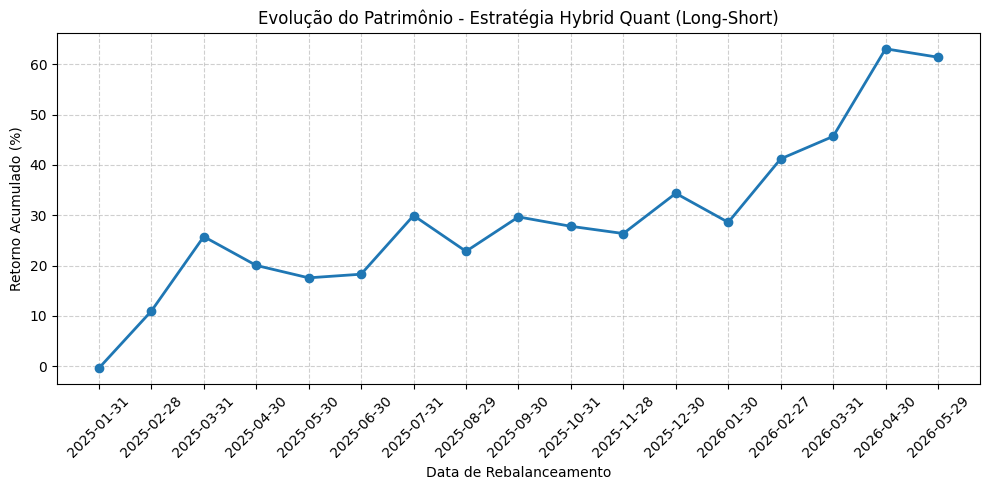

In [2]:
import matplotlib.pyplot as plt

# 1. Ajuste das datas para desconsiderar o último mês incompleto se necessário
retornos_validos = retorno_mensal[:-1] if retorno_mensal.index[-1].month == 6 else retorno_mensal

# 2. Cálculo das Métricas Quantitativas Principais
retorno_acumulado = (1 + retornos_validos).cumprod() - 1
sharpe_ratio = (retornos_validos.mean() / retornos_validos.std()) * np.sqrt(12)
max_drawdown = ((retorno_acumulado + 1) / (retorno_acumulado + 1).cummax() - 1).min()
win_rate = (retornos_validos > 0).mean() * 100

print(f"--- Métricas Finais da Estratégia ---")
print(f"Retorno Acumulado: {retorno_acumulado.iloc[-1] * 100:.2f}%")
print(f"Índice Sharpe Anualizado: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")
print(f"Taxa de Acerto (Win Rate): {win_rate:.1f}%")

# 3. Gráfico da Curva de Capital (Equity Curve)
plt.figure(figsize=(10, 5))
plt.plot(retorno_acumulado.index.astype(str), retorno_acumulado.values * 100, marker='o', linewidth=2, color='#1f77b4')
plt.title("Evolução do Patrimônio - Estratégia Hybrid Quant (Long-Short)")
plt.xlabel("Data de Rebalanceamento")
plt.ylabel("Retorno Acumulado (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()